In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/ML_Y_DL




archive			       Ml-pipeline-image-vector.ipynb
archive.zip		       Random_Forest_Alejandro.ipynb
bananaspruebajpg	       random_forest_model.pkl
dataset_fruit		       test
Efficente_Net_Alejandro.ipynb  test_dataset.csv
efficientnet_final.h5	       train
Kiwi			       train_dataset.csv
kiwipruebasjpg


In [3]:
!cp "/content/drive/MyDrive/ML_Y_DL/archive.zip" /content/imagenes.zip


In [4]:
!ls /content


drive  imagenes.zip  sample_data


In [5]:
!unzip /content/imagenes.zip -d /content/imagenes


Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: /content/imagenes/archive/Plum/PlumÒÇé404.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé405.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé406.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé407.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé408.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé409.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé41.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé410.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé411.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé412.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé413.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé414.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé415.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé416.png  
  inflating: /content/imagenes/archive/Plum/PlumÒÇé417.png  
  inflating: /content/ima

In [6]:
BASE_PATH = "/content/imagenes/archive"


In [7]:
!ls /content/imagenes/archive/Apple/Apple\ A | head


Apple 100.png
Apple 101.png
Apple 102.png
Apple 103.png
Apple 104.png
Apple 105.png
Apple 106.png
Apple 107.png
Apple 108.png
Apple 109.png


In [8]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/ML_Y_DL/train_dataset.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/ML_Y_DL/test_dataset.csv")


In [9]:
import os

def ruta_imagen(rel_path):
    return os.path.join(BASE_PATH, rel_path)


In [10]:
train_df.columns


Index(['Unnamed: 0', '0', 'fruta', 'percent', 'label_encoded'], dtype='object')

In [11]:
train_df.head()


,Unnamed: 0,0,fruta,percent,label_encoded
0,7491,Apple/Total Number of Apples/Apple 01463.png,Apple,15.855197,0
1,55445,Peach/Peach0092.png,Peach,3.726382,7
2,48975,muskmelon/Muskmelon 00931.png,muskmelon,2.945387,14
3,27743,Guava/Guava total/Guava。2200 resized.png,Guava,27.921645,3
4,54259,Peach/Peach001990.png,Peach,3.726382,7


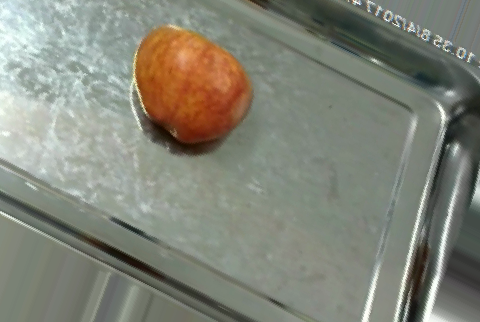

In [12]:
from PIL import Image

ruta = ruta_imagen(train_df.iloc[0]['0'])
img = Image.open(ruta)
img


In [13]:
from google.colab import files
files.upload()


Saving Ml-pipeline-image-vector.ipynb to Ml-pipeline-image-vector.ipynb


{'Ml-pipeline-image-vector.ipynb': b'{"nbformat":4,"nbformat_minor":0,"metadata":{"colab":{"provenance":[],"authorship_tag":"ABX9TyNBoxbWzNGvE7t5fqIAnz0n"},"kernelspec":{"name":"python3","display_name":"Python 3"},"language_info":{"name":"python"}},"cells":[{"cell_type":"code","source":["# -*- coding: utf-8 -*-\\n","\\"\\"\\"Pipeline Automatizado y Documentado de Clasificaci\xc3\xb3n Multiclase de Im\xc3\xa1genes.\\n","\\n","Este m\xc3\xb3dulo implementa un flujo de trabajo (pipeline) completo de Machine Learning\\n","tradicional para el tratamiento de im\xc3\xa1genes. Dise\xc3\xb1ado de extremo a extremo para\\n","realizar la carga f\xc3\xadsica de archivos, su transformaci\xc3\xb3n matem\xc3\xa1tica (vectorizaci\xc3\xb3n),\\n","normalizaci\xc3\xb3n estad\xc3\xadstica, partici\xc3\xb3n de validaci\xc3\xb3n, entrenamiento de modelos\\n","de ensamble y la exportaci\xc3\xb3n de artefactos para entornos de producci\xc3\xb3n.\\n","\\n","Arquitectura de la Vectorizaci\xc3\xb3n:\\n","    Par

In [14]:
# -*- coding: utf-8 -*-
"""Pipeline Automatizado y Documentado de Clasificación Multiclase de Imágenes.

Este módulo implementa un flujo de trabajo (pipeline) completo de Machine Learning
tradicional para el tratamiento de imágenes. Diseñado de extremo a extremo para
realizar la carga física de archivos, su transformación matemática (vectorización),
normalización estadística, partición de validación, entrenamiento de modelos
de ensamble y la exportación de artefactos para entornos de producción.

Arquitectura de la Vectorización:
    Para algoritmos de Machine Learning tradicionales (como Random Forest), una imagen
    bidimensional de dimensiones (H, W) debe convertirse en una estructura de datos
    unidimensional compatible. Este proceso ('flattening' o aplanado) estira los píxeles
    de la matriz transformándolos en un vector lineal en un espacio vectorial de R^D,
    donde D = H * W * Canales.

Estructura de Carpetas Requerida para el Dataset:
    RAÍZ_DATASET/
    ├── clase_A/
    │   ├── img01.jpg
    │   └── img02.jpg
    ├── clase_B/
    │   └── img01.jpg
    └── clase_C/
        └── img01.jpg
"""

import os
import cv2
import joblib
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ==============================================================================
# CONFIGURACIÓN DE PARÁMETROS GLOBALES Y METADATOS
# ==============================================================================
DATASET_DIR = "mi_dataset_automatizado"  # Directorio donde residen las clases de imágenes
MODEL_NAME = "clasificador_imagenes_ml.pkl"  # Archivo binario para el modelo exportado
SCALER_NAME = "escalador_imagenes.pkl"  # Parámetros mu y sigma del StandardScaler
ENCODER_NAME = "codificador_etiquetas.pkl"  # Mapeo de texto a ID numérico de clases
IMG_SIZE = (64, 64)  # Dimensiones geométricas estándar (Ancho, Alto) para reescalado


def crear_dataset_de_prueba():
    """Generador Sintético de Entorno y Datos de Prueba.

    Verifica la existencia del directorio objetivo. En caso de ausencia, simula
    la existencia de un dataset real creando carpetas por clase e inyectando
    matrices de ruido aleatorio uniforme en formato JPEG. Su función es permitir
    la ejecución inmediata del script en modalidad 'Plug and Play'.
    """
    if not os.path.exists(DATASET_DIR):
        os.makedirs(DATASET_DIR)
        clases_ejemplo = ["gato", "perro", "pajaro"]
        print("[INFO] Creando entorno de prueba con imágenes sintéticas...")

        for clase in clases_ejemplo:
            ruta_clase = os.path.join(DATASET_DIR, clase)
            os.makedirs(ruta_clase, exist_ok=True)

            # Inyectar 30 muestras de ruido uniforme por categoría
            for i in range(30):
                # Generar matriz numérica entera aleatoria en rango
                img_falsa = np.random.randint(
                    0, 256, (100, 100), dtype=np.uint8
                )
                # Persistir la matriz en disco simulando una captura física de cámara
                cv2.imwrite(os.path.join(ruta_clase, f"img_{i}.jpg"), img_falsa)
        print("[INFO] ¡Dataset de prueba generado exitosamente!\n")


def cargar_y_vectorizar(ruta_raiz, target_size):
    """Proceso ETL (Extract, Transform, Load) y Vectorización Espacial.

    Este método lee los archivos binarios de imagen desde el disco, reduce su
    complejidad mediante conversión cromática, estandariza sus límites geométricos
    y ejecuta la reducción dimensional de matriz 2D a un vector lineal 1D.

    Args:
        ruta_raiz (str): Ruta absoluta o relativa de la carpeta base del dataset.
        target_size (tuple): Dimensiones de destino configuradas como (ancho, alto).

    Returns:
        tuple: Un par de matrices NumPy que contienen:
            - X (np.ndarray): Matriz de diseño bidimensional de dimensiones
              [N_Muestras, N_Características] (donde N_Características = H * W).
            - y (np.ndarray): Vector unidimensional de tipo string [N_Muestras]
              con las etiquetas textuales extraídas de los nombres de las carpetas.

    Raises:
        FileNotFoundError: Si la ruta base especificada no existe en el sistema.
    """
    X = []
    y = []

    if not os.path.exists(ruta_raiz):
        raise FileNotFoundError(f"Error Crítico: El directorio {ruta_raiz} no existe.")

    # Iterar sobre las subcarpetas del directorio raíz (cada subcarpeta representa una clase única)
    for clase in os.listdir(ruta_raiz):
        ruta_clase = os.path.join(ruta_raiz, clase)

        if os.path.isdir(ruta_clase):
            # Inspeccionar y procesar de forma secuencial cada archivo de la clase actual
            for archivo in os.listdir(ruta_clase):
                ruta_img = os.path.join(ruta_clase, archivo)

                # 1. Extracción e Inferencia Cromática:
                # Se fuerza la lectura a Escala de Grises (1 solo canal de intensidad de brillo).
                # Elimina la correlación por color y disminuye los requerimientos de RAM en un 66%.
                img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)

                if img is not None:
                    # 2. Redimensionamiento Homogéneo:
                    # Interpola los píxeles para forzar una resolución matemática fija (ej. 64x64).
                    img_resized = cv2.resize(img, target_size)

                    # 3. Vectorización (Aplanar / Flattening):
                    # Rompe la estructura matricial 2D (64, 64) y la estira en un array 1D de (4096,).
                    img_vector = img_resized.flatten()

                    # Acumular los vectores numéricos y sus etiquetas en las estructuras temporales
                    X.append(img_vector)
                    y.append(clase)

    return np.array(X), np.array(y)


# ==============================================================================
# PIPELINE DE INGENIERÍA DE DATOS Y ENTRENAMIENTO
# ==============================================================================
if __name__ == "__main__":
    # Inicializar el entorno generando datos si el usuario no cuenta con un dataset local
    crear_dataset_de_prueba()

    # --------------------------------------------------------------------------
    # FASE 1: Carga de Datos y Vectorización
    # --------------------------------------------------------------------------
    print("[1/5] Iniciando lectura física de imágenes y vectorización...")
    X, y = cargar_y_vectorizar(DATASET_DIR, IMG_SIZE)
    print(f"      -> Matriz de Diseño resultante (X): {X.shape} [Muestras, Características]")
    print(f"      -> Vector de Etiquetas original (y): {y.shape} [Muestras]")

    # --------------------------------------------------------------------------
    # FASE 2: Preprocesamiento de Datos y Normalización
    # --------------------------------------------------------------------------
    print("\n[2/5] Ejecutando codificación de categorías y normalización estadística...")

    # Codificación de Etiquetas (Label Encoding):
    # Convierte variables cualitativas ordinales ('gato', 'perro') en enteros puros
    # requeridos por la función de pérdida del clasificador multiclase.
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Partición del Dataset (Hold-out Validation):
    # Reserva un 25% de la información vectorizada para pruebas ciegas de generalización.
    # El argumento 'stratify' preserva estrictamente la proporción de clases en ambas particiones.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
    )

    # Escalado de Características (Z-Score Normalization):
    # Centra la distribución calculando la media espacial y dividiendo por la desviación estándar.
    # Fórmula matemática aplicada: z = (x - mu) / sigma
    # Garantiza estabilidad matemática al evitar que píxeles con variaciones atípicas sesguen el gradiente o el corte del árbol.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # Ajusta parámetros (mu, sigma) y transforma el set de entrenamiento
    X_test_scaled = scaler.transform(X_test)  # Aplica la transformación idéntica sobre el set de test de forma aislada

    # --------------------------------------------------------------------------
    # FASE 3: Modelado Estadístico (Entrenamiento)
    # --------------------------------------------------------------------------
    print("\n[3/5] Instanciando y entrenando Clasificador Random Forest Multiclase...")

    # Configuración de Bosques Aleatorios:
    # Algoritmo de ensamble que combina múltiples árboles de decisión mediante Bagging.
    # - n_estimators=150: Instancia 150 estimadores independientes para mitigar la varianza.
    # - n_jobs=-1: Ordena al planificador del sistema operativo explotar todos los hilos de la CPU de forma síncrona.
    modelo = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
    modelo.fit(X_train_scaled, y_train)

    # --------------------------------------------------------------------------
    # FASE 4: Inferencia de Validación y Métricas Científicas
    # --------------------------------------------------------------------------
    print("\n[4/5] Evaluando métricas del modelo sobre datos no observados...")
    predicciones = modelo.predict(X_test_scaled)

    # Computar el porcentaje global de aciertos directos (Exactitud / Accuracy)
    exactitud = accuracy_score(y_test, predicciones)
    print(f"      -> Exactitud Global del Sistema (Accuracy): {exactitud:.2f}")
    print("\nReporte de Clasificación Extendido por Categoría:")

    # Desglose estadístico avanzado que evalúa:
    # - Precisión: Capacidad de no clasificar una muestra falsa como positiva.

[INFO] Creando entorno de prueba con imágenes sintéticas...
[INFO] ¡Dataset de prueba generado exitosamente!

[1/5] Iniciando lectura física de imágenes y vectorización...
      -> Matriz de Diseño resultante (X): (90, 4096) [Muestras, Características]
      -> Vector de Etiquetas original (y): (90,) [Muestras]

[2/5] Ejecutando codificación de categorías y normalización estadística...

[3/5] Instanciando y entrenando Clasificador Random Forest Multiclase...

[4/5] Evaluando métricas del modelo sobre datos no observados...
      -> Exactitud Global del Sistema (Accuracy): 0.39

Reporte de Clasificación Extendido por Categoría:


## RANDOM FOREST - MACHINE LEARNING

In [ ]:
# import joblib

# Cargar modelo Random Forest desde Drive

# rf = joblib.load("/content/drive/MyDrive/random_forest_model.pkl")

# print("Modelo cargado correctamente.")


In [15]:
import os
import cv2
import numpy as np

def cargar_y_vectorizar(ruta_raiz, target_size):
    X = []
    y = []

    # Recorre cada clase (carpeta principal)
    for clase in os.listdir(ruta_raiz):
        ruta_clase = os.path.join(ruta_raiz, clase)

        # Recorre TODAS las subcarpetas y archivos dentro de la clase
        for root, dirs, files in os.walk(ruta_clase):
            for archivo in files:
                # Extensiones válidas
                if archivo.lower().endswith((".jpg", ".jpeg", ".png")):
                    ruta_imagen = os.path.join(root, archivo)

                    # Cargar imagen
                    img = cv2.imread(ruta_imagen)
                    if img is None:
                        continue

                    # Convertir a gris
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                    # Redimensionar
                    img = cv2.resize(img, target_size)

                    # Aplanar
                    img = img.flatten()

                    X.append(img)
                    y.append(clase)

    return np.array(X), np.array(y)


In [16]:
X, y = cargar_y_vectorizar("/content/imagenes/archive", (64, 64))


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separar train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% para test
    random_state=42,
    stratify=y            # mantiene proporciones de clases
)

# 2. Crear el modelo
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    n_jobs=-1,
    random_state=42,
    verbose=1             # para ver progreso
)

# 3. Entrenar
rf.fit(X_train, y_train)

# 4. Evaluar
preds = rf.predict(X_test)

print("Accuracy en test:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed: 10.6min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 16.0min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.6s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.7s


Accuracy en test: 0.8788093550673282
              precision    recall  f1-score   support

       Apple       0.58      1.00      0.73      2237
      Banana       0.99      0.72      0.83       606
   Carambola       1.00      0.70      0.83       416
       Guava       1.00      0.97      0.98      3940
        Kiwi       1.00      0.94      0.97      1693
       Mango       0.98      0.72      0.83       831
      Orange       0.97      0.69      0.81       602
       Peach       1.00      0.80      0.89       526
        Pear       1.00      0.72      0.83       602
   Persimmon       1.00      0.77      0.87       414
      Pitaya       1.00      0.84      0.91       500
        Plum       1.00      1.00      1.00       460
 Pomegranate       0.98      0.82      0.89       433
    Tomatoes       0.98      0.73      0.84       434
   muskmelon       1.00      0.76      0.86       416

    accuracy                           0.88     14110
   macro avg       0.96      0.81      0.87

[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    2.3s finished


In [19]:
print("Accuracy:", accuracy_score(y_test, preds))
print("Precision (macro):", precision_score(y_test, preds, average='macro'))
print("Recall (macro):", recall_score(y_test, preds, average='macro'))
print("F1-macro:", f1_score(y_test, preds, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, preds))



Accuracy: 0.8788093550673282
Precision (macro): 0.964397800288243
Recall (macro): 0.8104251145637082
F1-macro: 0.8708710937284551

Classification Report:
              precision    recall  f1-score   support

       Apple       0.58      1.00      0.73      2237
      Banana       0.99      0.72      0.83       606
   Carambola       1.00      0.70      0.83       416
       Guava       1.00      0.97      0.98      3940
        Kiwi       1.00      0.94      0.97      1693
       Mango       0.98      0.72      0.83       831
      Orange       0.97      0.69      0.81       602
       Peach       1.00      0.80      0.89       526
        Pear       1.00      0.72      0.83       602
   Persimmon       1.00      0.77      0.87       414
      Pitaya       1.00      0.84      0.91       500
        Plum       1.00      1.00      1.00       460
 Pomegranate       0.98      0.82      0.89       433
    Tomatoes       0.98      0.73      0.84       434
   muskmelon       1.00      0.76  

Random Forest ha entrenado correctamente

Ha evaluado sobre test

Ha conseguido 88% de accuracy, que es muy bueno

Las métricas por clase son sólidas

El modelo está listo para usarse en producción o predicciones nuevas

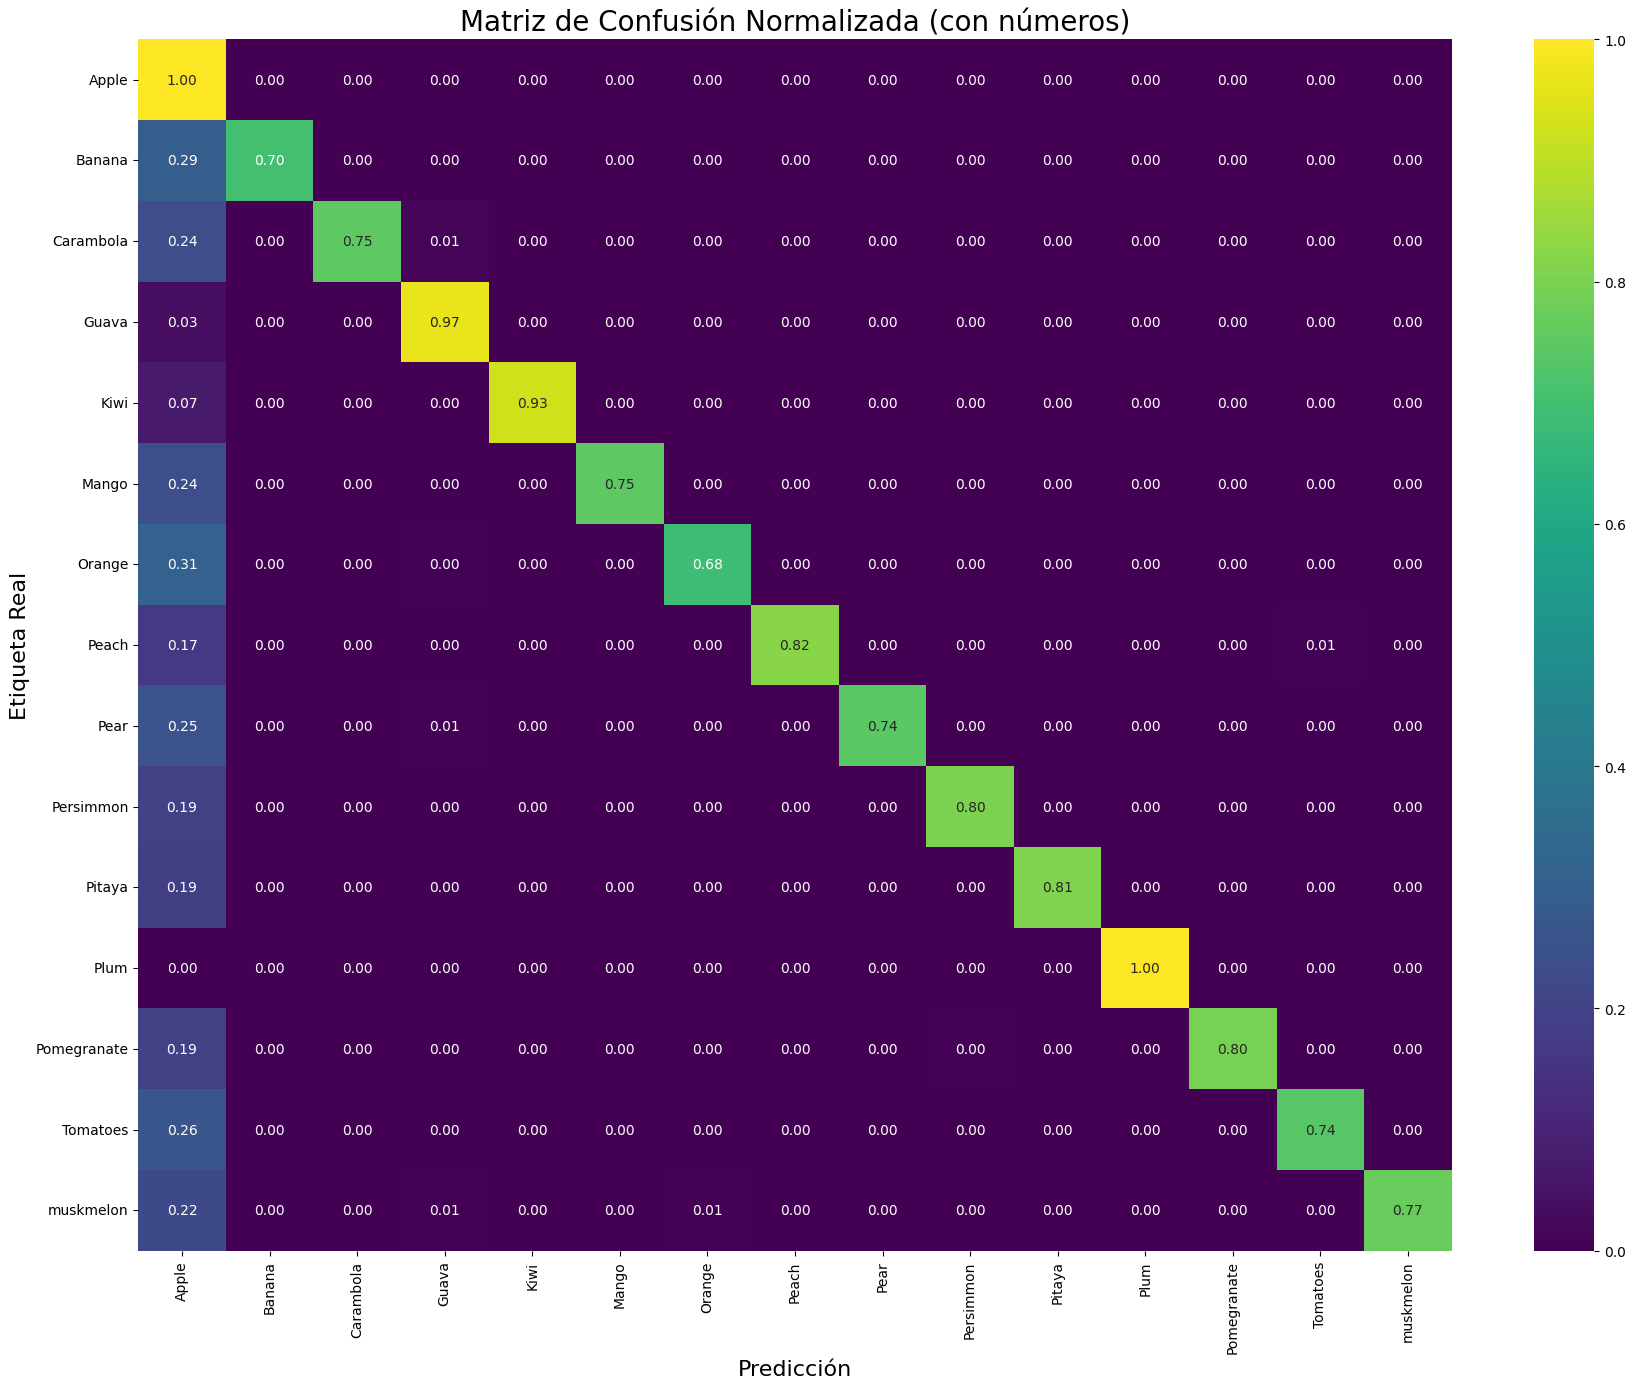

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Clases detectadas en el test
classes = np.unique(y_test)

# Matriz de confusión normalizada (porcentaje por clase real)
cm_norm = confusion_matrix(y_test, preds, normalize='true')

plt.figure(figsize=(18, 14))
sns.heatmap(
    cm_norm,
    annot=True,          # ← muestra los números
    fmt=".2f",           # ← formato de los números
    cmap="viridis",      # ← colores bonitos
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Matriz de Confusión Normalizada (con números)", fontsize=20)
plt.xlabel("Predicción", fontsize=16)
plt.ylabel("Etiqueta Real", fontsize=16)
plt.tight_layout()
plt.show()



In [ ]:
import joblib

# Guardar modelo Random Forest
joblib.dump(rf, "random_forest_model.pkl")

print("Modelo guardado correctamente.")


Modelo guardado correctamente.


In [ ]:
from google.colab import files

files.download("random_forest_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## RANDOM FOREST - PREPROCESADO Y PREDICCIÓN


In [ ]:
import joblib
import cv2
import numpy as np
from google.colab import drive


In [ ]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
joblib.dump(rf, "random_forest_model.pkl")


['random_forest_model.pkl']

In [ ]:
!ls /content


drive	  imagenes.zip		   Ml-pipeline-image-vector.ipynb  sample_data
imagenes  mi_dataset_automatizado  random_forest_model.pkl


In [ ]:
!mv /content/random_forest_model.pkl /content/drive/MyDrive/


In [ ]:
rf = joblib.load("/content/drive/MyDrive/random_forest_model.pkl")
print("Modelo cargado correctamente.")


Modelo cargado correctamente.


In [ ]:
img = cv2.imread("/content/drive/MyDrive/ML_Y_DL/Kiwi A002-prueba dataset.png")


In [ ]:
print(img is None)


False


In [ ]:
!ls /content/drive/MyDrive/ML_Y_DL


 archive			 Ml-pipeline-image-vector.ipynb
 archive.zip			 Random_Forest_Alejandro.ipynb
 bananas-prueba.jpg		 random_forest_model.pkl
'Kiwi A002-prueba dataset.png'	 test_dataset.csv
 kiwi-pruebas.jpg		 train_dataset.csv


In [ ]:
print(os.listdir("/content/drive/MyDrive/"))
print(os.listdir("/content/drive/MyDrive/ML_Y_DL"))

['Colab Notebooks', 'netflix_eda_student.ipynb', 'proyecto_júpiter_analisis_exploratorio.ipynb', 'creacion_tablas.ipynb', 'creacion_tablas_definitivo.ipynb', 'Introducción al ML-TODO.ipynb', 'Actividad 3 - PBI - Alejandro Torrecilla.pbix', 'Mapa sin nombre.gmap', 'Copia de RESUMEN_FUNCIONES_MASTER.pdf', 'ANN_Alejandro_Torrecilla.ipynb', 'actividad_sesion_02.ipynb', 'Transformer.ipynb', '2.langchain_avanzado (3).ipynb', 'ML_Y_DL', 'Ml-pipeline-image-vector.ipynb', 'random_forest_model.pkl']
['test_dataset.csv', 'train_dataset.csv', 'archive.zip', 'Ml-pipeline-image-vector.ipynb', 'archive', 'random_forest_model.pkl', 'bananas-prueba.jpg', 'kiwi-pruebas.jpg', 'Kiwi A002-prueba dataset.png', 'Random_Forest_Alejandro.ipynb']


In [ ]:
import cv2
import numpy as np

# Cargar imagen nueva desde Drive (ruta correcta)
img = cv2.imread("/content/drive/MyDrive/ML_Y_DL/Kiwi A002-prueba dataset.png")

# Comprobar que se ha cargado
print(img is None)

# Convertir a blanco y negro (1 canal)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Redimensionar
img = cv2.resize(img, (64, 64))

# Convertir a vector
vector = img.flatten().reshape(1, -1)

# Predicción
pred = rf.predict(vector)
print("Predicción:", pred[0])




False
Predicción: Kiwi


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.2s finished
